In [1]:
import os 
import regex as re
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from locscale.include.emmer.ndimage.map_utils import load_map

In [2]:
parent_folder_all_feature_enhance_maps = "/tudelft/abharadwaj1/staff-umbrella/ajlab/AB/parking_for_files/fromHPC/feature_enhance_test_maps_with_proper_pvddt_values"
emdb_pdb_list = [x for x in os.listdir(parent_folder_all_feature_enhance_maps)]

times_all = {}
for emdb_pdb in emdb_pdb_list:
    emdb, pdb = emdb_pdb.split("_")
    emdb_folder = os.path.join(parent_folder_all_feature_enhance_maps, emdb_pdb)
    locscale_log_file = os.path.join(emdb_folder, "processing_files", "locscale.log")
    final_output_map = os.path.join(emdb_folder, f"emd_{emdb}_emmernet_output_locscale_output.mrc")	

    if not os.path.exists(locscale_log_file) or not os.path.exists(final_output_map):
        continue
    
    emmap, apix = load_map(final_output_map)
    map_shape = emmap.shape[0]
    with open(locscale_log_file, "r") as f:
        log_lines = f.readlines()
    
    # first line has 2023-09-29 at 14:14:05 | INFO | Starting LocScale program
    start_time_str = re.search(r"(\d{4}-\d{2}-\d{2} at \d{2}:\d{2}:\d{2})", log_lines[0]).group(1)
    year_month_day, time_str = start_time_str.split(" at ")
    year, month, day = map(int, year_month_day.split("-"))
    hour, minute, second = map(int, time_str.split(":"))
    start_time = np.datetime64(f"{year}-{month:02d}-{day:02d}T{hour:02d}:{minute:02d}:{second:02d}")
    
    # time to complete emmernet prediction using 2023-08-14 at 18:39:14 | INFO | Running LocScale
    # search for the line with "Running LocScale" and get the timestamp
    emmernet_prediction_time_line = [line for line in log_lines if "| INFO | Running LocScale" in line][0]
    emmernet_prediction_time_str = re.search(r"(\d{4}-\d{2}-\d{2} at \d{2}:\d{2}:\d{2})", emmernet_prediction_time_line).group(1)
    year_month_day, time_str = emmernet_prediction_time_str.split(" at ")
    year, month, day = map(int, year_month_day.split("-"))
    hour, minute, second = map(int, time_str.split(":"))
    emmernet_prediction_time = np.datetime64(f"{year}-{month:02d}-{day:02d}T{hour:02d}:{minute:02d}:{second:02d}")

    # time to end 
    os_time_save = os.path.getmtime(final_output_map)
    end_datetime = datetime.fromtimestamp(os_time_save)
    final_output_map_time = np.datetime64(end_datetime)
    print(f"{emdb_pdb}: Time taken for locscale to run: {(final_output_map_time - start_time) / np.timedelta64(1, 's')} seconds | Map shape: {map_shape} | Apix: {apix}")

    time_to_predict_emmernet = (emmernet_prediction_time - start_time) / np.timedelta64(1, 's')
    time_to_run_locscale = (final_output_map_time - emmernet_prediction_time) / np.timedelta64(1, 's')
    total_time = (final_output_map_time - start_time) / np.timedelta64(1, 's')

    times_all[emdb_pdb] = {
        "start_time": start_time,
        "emmernet_prediction_time": emmernet_prediction_time,
        "final_output_map_time": final_output_map_time,
        "map_shape": map_shape,
        "apix": apix,
        "time_to_predict_emmernet": time_to_predict_emmernet,
        "time_to_run_locscale": time_to_run_locscale,
        "total_time": total_time
    }

0282_6huo: Time taken for locscale to run: 1239.27943 seconds | Map shape: 256 | Apix: 1.0700000127156575
0311_6hz5: Time taken for locscale to run: 695.308003 seconds | Map shape: 240 | Apix: 1.0499999523162842
0560_6nzu: Time taken for locscale to run: 292.087671 seconds | Map shape: 200 | Apix: 1.0859999656677246
10365_6t23: Time taken for locscale to run: 470.212729 seconds | Map shape: 256 | Apix: 1.0499999523162842
20220_6oxl: Time taken for locscale to run: 298.860398 seconds | Map shape: 300 | Apix: 1.1600000063578289
20226_6p07: Time taken for locscale to run: 332.689133 seconds | Map shape: 256 | Apix: 1.1499999364217122
3545_5mqf: Time taken for locscale to run: 4045.776325 seconds | Map shape: 360 | Apix: 1.5899999936421711
4141_5m1s: Time taken for locscale to run: 178.510738 seconds | Map shape: 140 | Apix: 1.7599999109903972
4531_6qdw: Time taken for locscale to run: 2594.256299 seconds | Map shape: 480 | Apix: 1.0499999523162842
4571_6qk7: Time taken for locscale to run

In [3]:
import pandas as pd
df = pd.DataFrame.from_dict(times_all, orient="index")
df


,start_time,emmernet_prediction_time,final_output_map_time,map_shape,apix,time_to_predict_emmernet,time_to_run_locscale,total_time
0282_6huo,2023-08-14 16:15:59,2023-08-14 16:32:10,2023-08-14 16:36:38.279430,256,1.0700,971.0,268.279430,1239.279430
0311_6hz5,2023-08-14 16:36:47,2023-08-14 16:41:46,2023-08-14 16:48:22.308003,240,1.0500,299.0,396.308003,695.308003
0560_6nzu,2023-08-14 16:48:29,2023-08-14 16:50:49,2023-08-14 16:53:21.087671,200,1.0860,140.0,152.087671,292.087671
10365_6t23,2023-08-14 16:53:27,2023-08-14 16:56:49,2023-08-14 17:01:17.212729,256,1.0500,202.0,268.212729,470.212729
20220_6oxl,2023-08-14 17:01:25,2023-08-14 17:03:55,2023-08-14 17:06:23.860398,300,1.1600,150.0,148.860398,298.860398
20226_6p07,2023-08-14 17:06:32,2023-08-14 17:09:14,2023-08-14 17:12:04.689133,256,1.1500,162.0,170.689133,332.689133
3545_5mqf,2023-08-14 17:12:12,2023-08-14 18:11:13,2023-08-14 18:19:37.776325,360,1.5900,3541.0,504.776325,4045.776325
4141_5m1s,2023-08-14 18:19:54,2023-08-14 18:22:26,2023-08-14 18:22:52.510738,140,1.7600,152.0,26.510738,178.510738
4531_6qdw,2023-08-14 18:22:58,2023-08-14 18:39:14,2023-08-14 19:06:12.256299,480,1.0500,976.0,1618.256299,2594.256299
4571_6qk7,2023-08-14 19:06:40,2023-08-14 19:14:59,2023-08-14 19:18:59.929134,290,1.3500,499.0,240.929134,739.929134


/tmp/ipykernel_30402/2300664351.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels, rotation=45, ha="right")


FileNotFoundError: [Errno 2] No such file or directory: '/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/data/rebuttal/locscale_time_plot.pdf'

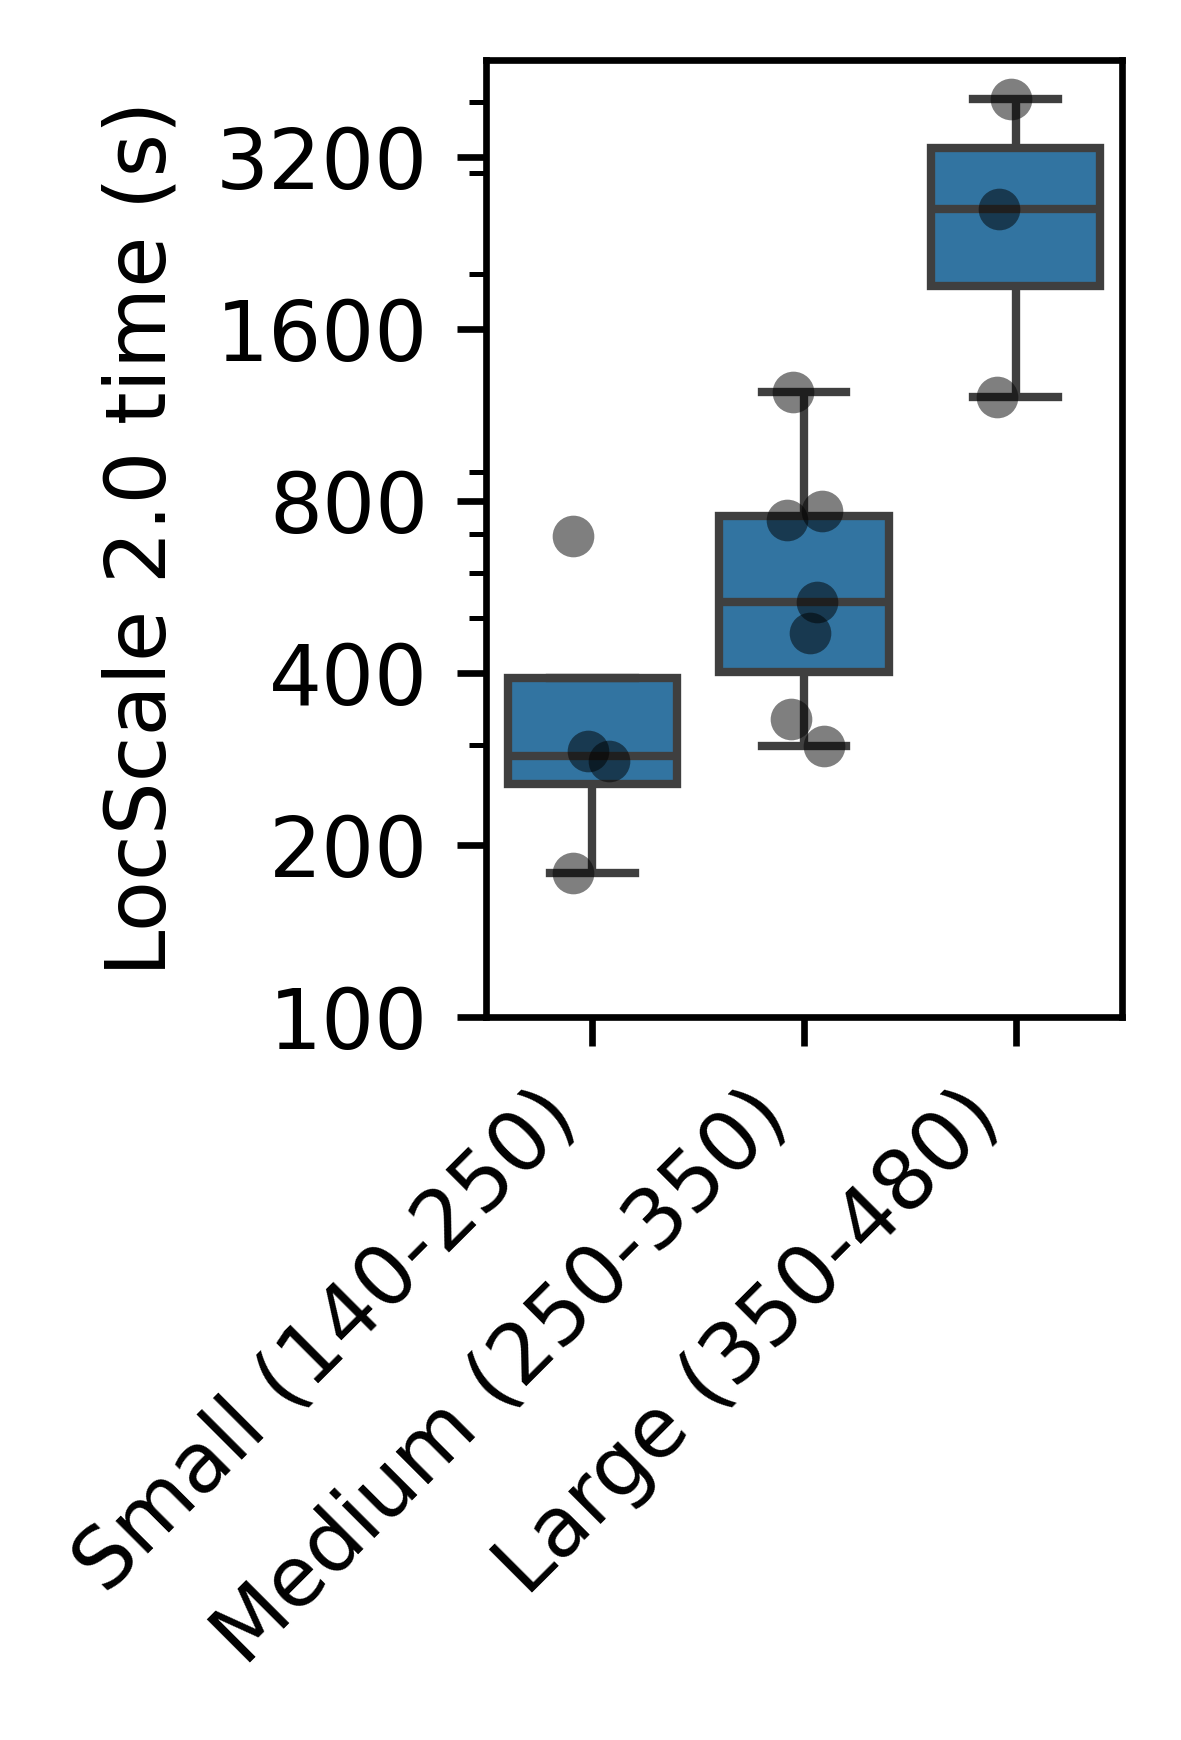

In [5]:
from matplotlib import rcParams
rcParams["pdf.fonttype"] = 42
# plot the time to predict emmernet and time to run locscale as a boxplot using seaborn by grouped by map shape (small: <250, medium: 250-350, large: >350)
small_limit = 250
medium_limit = 350
df["map_size_category"] = df["map_shape"].apply(lambda x: "1_small" if x < small_limit else ("2_medium" if x < medium_limit else "3_large"))
# show small to the left, medium in the middle and large to the right
fig, ax = plt.subplots(figsize=(2, 3), dpi=600)

sns.boxplot(x="map_size_category", y="total_time", data=df, order=["1_small", "2_medium", "3_large"], ax=ax, showfliers=False)
sns.stripplot(x="map_size_category", y="total_time", data=df, color="black", alpha=0.5, order=["1_small", "2_medium", "3_large"], ax=ax)
xlabels = ["Small (140-250)", "Medium (250-350)", "Large (350-480)"]
ax.set_xticklabels(xlabels, rotation=45, ha="right")
ax.set_ylabel("LocScale 2.0 time (s)")
ax.set_yscale("log")
yticks = [100, 200, 400, 800, 1600, 3200]
ax.set_yticks(yticks)
ax.set_yticklabels(yticks)
ax.set_xlabel("")
save_path = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/data/rebuttal/locscale_time_plot.pdf"
plt.tight_layout()
plt.savefig(save_path)

csv_path = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/data/rebuttal/locscale_time_data.csv"
df.to_csv(csv_path)



/tmp/ipykernel_16122/2160218537.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels, rotation=45, ha="right")


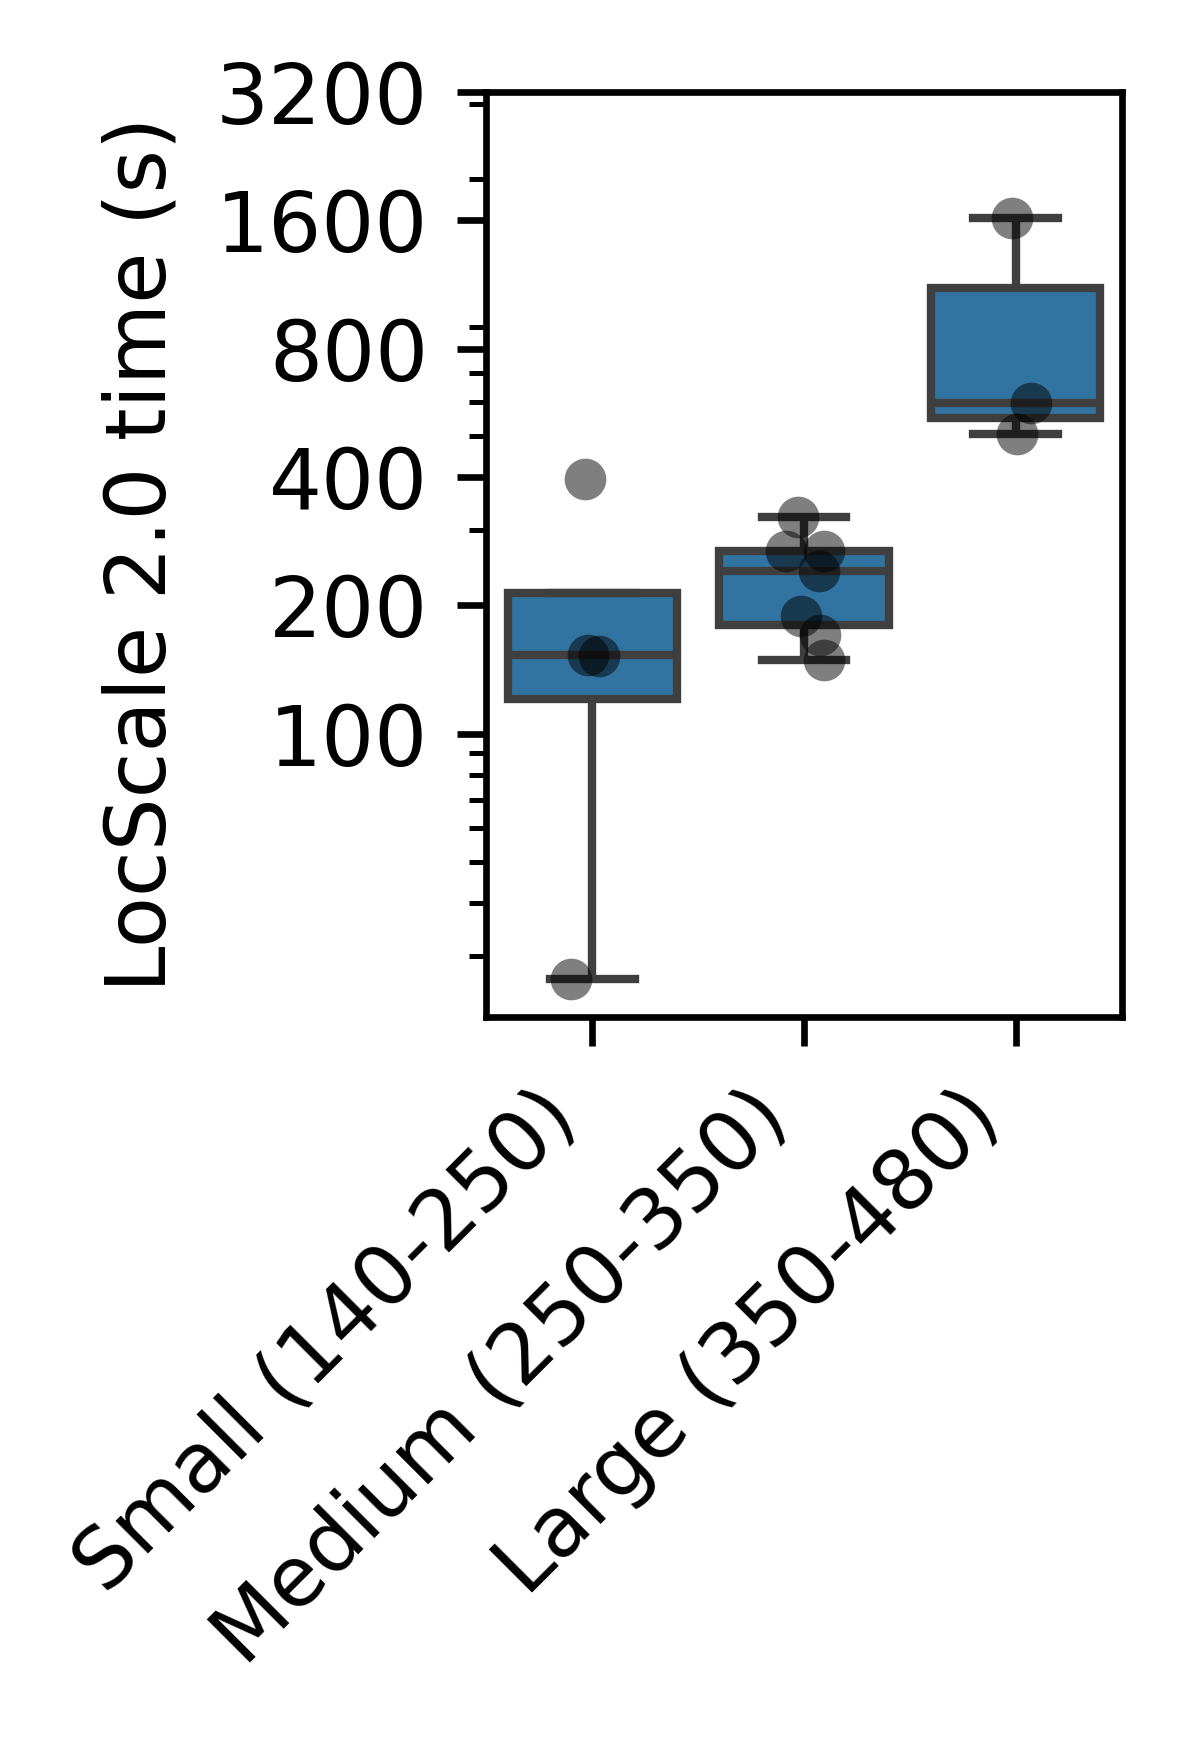

In [ ]:
from matplotlib import rcParams
rcParams["pdf.fonttype"] = 42
# plot the time to predict emmernet and time to run locscale as a boxplot using seaborn by grouped by map shape (small: <250, medium: 250-350, large: >350)
small_limit = 250
medium_limit = 350
df["map_size_category"] = df["map_shape"].apply(lambda x: "1_small" if x < small_limit else ("2_medium" if x < medium_limit else "3_large"))
# show small to the left, medium in the middle and large to the right
fig, ax = plt.subplots(figsize=(2, 3), dpi=600)

sns.boxplot(x="map_size_category", y="time_to_run_locscale", data=df, order=["1_small", "2_medium", "3_large"], ax=ax, showfliers=False)
sns.stripplot(x="map_size_category", y="time_to_run_locscale", data=df, color="black", alpha=0.5, order=["1_small", "2_medium", "3_large"], ax=ax)
xlabels = ["Small (140-250)", "Medium (250-350)", "Large (350-480)"]
ax.set_xticklabels(xlabels, rotation=45, ha="right")
ax.set_ylabel("LocScale 2.0 time (s)")
ax.set_yscale("log")
yticks = [100, 200, 400, 800, 1600, 3200]
ax.set_yticks(yticks)
ax.set_yticklabels(yticks)
ax.set_xlabel("")
save_path = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/data/rebuttal/locscale_time_plot_2.pdf"
plt.tight_layout()
plt.savefig(save_path)



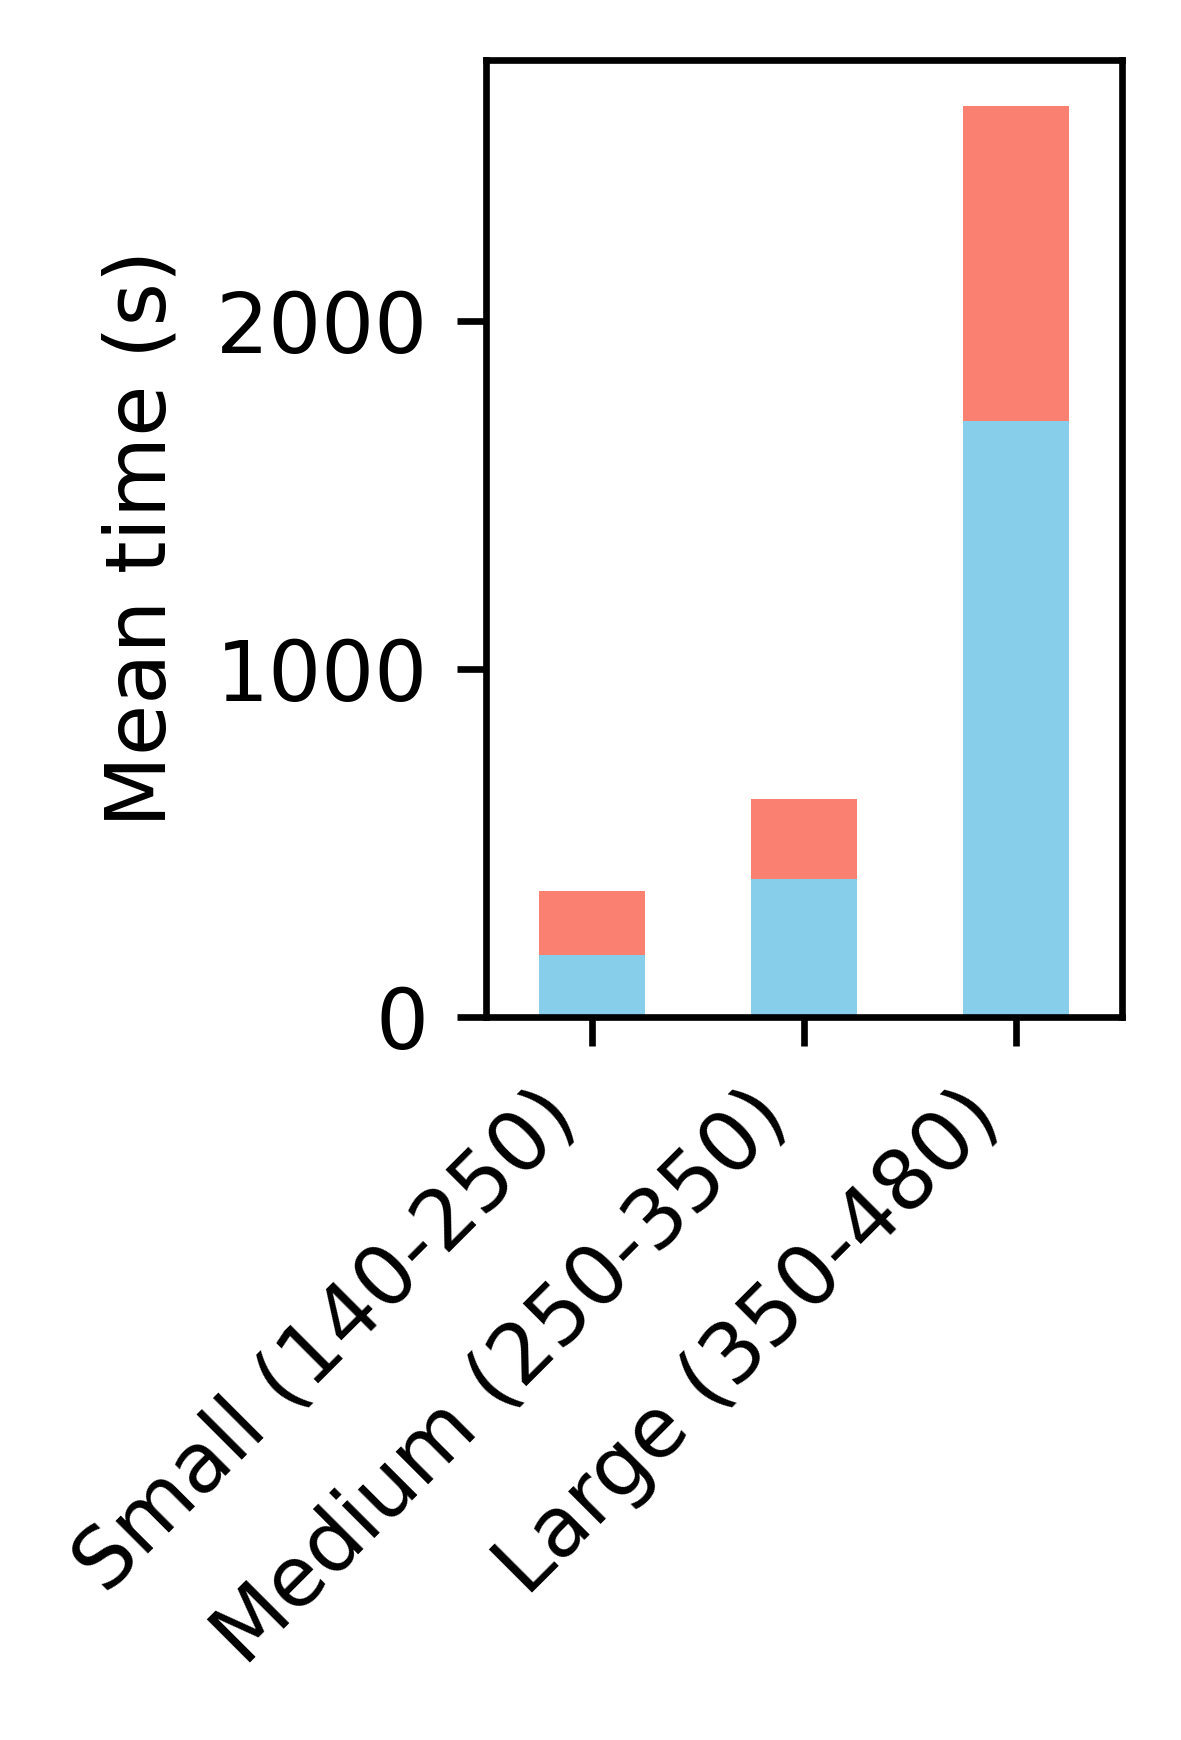

In [ ]:
# show a stacked bar plot with mean time to predict emmernet and mean time to run locscale for each map size category
mean_times = df.groupby("map_size_category")[["time_to_predict_emmernet", "time_to_run_locscale"]].mean()
fig, ax = plt.subplots(figsize=(2, 3), dpi=600)
mean_times.plot(kind="bar", stacked=True, ax=ax, color=["skyblue", "salmon"])
xlabels = ["Small (140-250)", "Medium (250-350)", "Large (350-480)"]
ax.set_xticklabels(xlabels, rotation=45, ha="right")
ax.set_ylabel("Mean time (s)")
#ax.set_yscale("log")
# yticks = [100, 200, 400, 800, 1600, 3200]
# ax.set_yticks(yticks)
# ax.set_yticklabels(yticks)
ax.set_xlabel("")
save_path = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/data/rebuttal/locscale_time_plot_stacked_bar.pdf"
# hide legend
ax.legend().set_visible(False)
plt.tight_layout()
plt.savefig(save_path)